# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

**Business Understanding Response:**

The business objective is to help a used car dealership understand which vehicle attributes most significantly influence resale price. From a data science perspective, this translates to a **supervised regression problem**: we aim to build a predictive model where the **target variable is listing price** (continuous numeric) and the **features are vehicle attributes** such as year, odometer reading, manufacturer, condition, fuel type, transmission, and drive type.

Success is measured by the model's ability to explain price variance (R²) and minimize prediction error (RMSE). The actionable output is a ranked list of features with their coefficients, indicating which factors positively or negatively impact price — enabling the dealership to make data-driven inventory acquisition and pricing decisions.

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
# Load dataset
df = pd.read_csv('data/vehicles.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (426880, 18)


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [3]:
print('Column dtypes:')
print(df.dtypes)
print('\nBasic statistics:')
df.describe()

Column dtypes:
id                int64
region              str
price             int64
year            float64
manufacturer        str
model               str
condition           str
cylinders           str
fuel                str
odometer        float64
title_status        str
transmission        str
VIN                 str
drive               str
size                str
type                str
paint_color         str
state               str
dtype: object

Basic statistics:


,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

Columns with missing values:
              Missing Count  Missing %
size                 306361       71.8
cylinders            177678       41.6
condition            174104       40.8
VIN                  161042       37.7
drive                130567       30.6
paint_color          130203       30.5
type                  92858       21.8
manufacturer          17646        4.1
title_status           8242        1.9
model                  5277        1.2
odometer               4400        1.0
fuel                   3013        0.7
transmission           2556        0.6
year                   1205        0.3


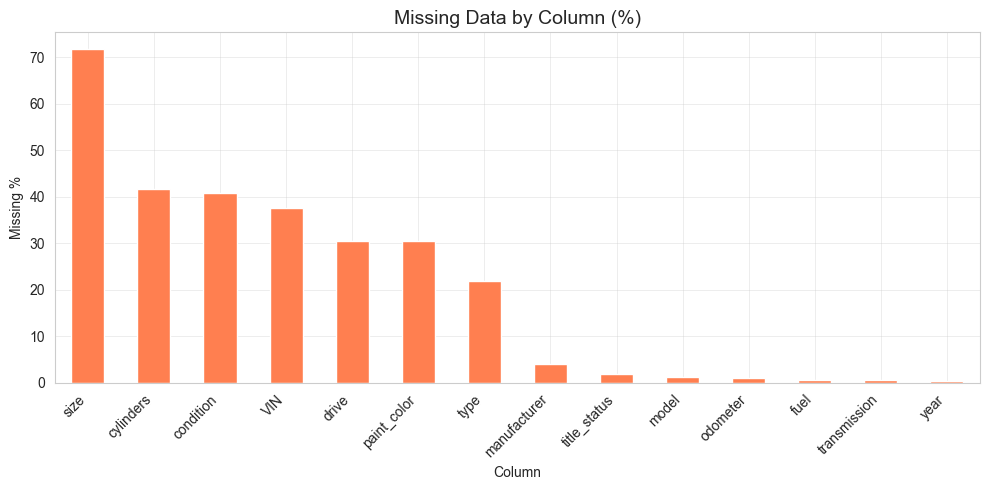

In [4]:
# Missing value analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('Columns with missing values:')
print(missing_df)

fig, ax = plt.subplots(figsize=(10, 5))
missing_df['Missing %'].plot(kind='bar', ax=ax, color='coral')
ax.set_title('Missing Data by Column (%)', fontsize=14)
ax.set_ylabel('Missing %')
ax.set_xlabel('Column')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

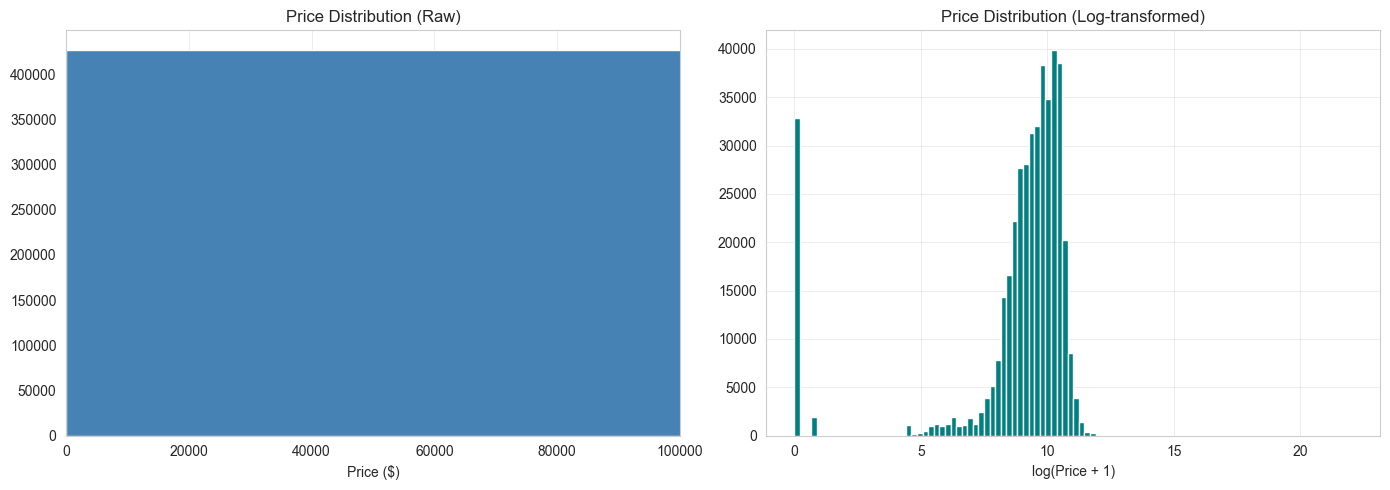

Price stats — min: $0, max: $3,736,928,711, median: $13,950, mean: $75,199


In [5]:
# Price distribution — raw and log-transformed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Raw)')
axes[0].set_xlabel('Price ($)')
axes[0].set_xlim(0, 100000)

log_prices = np.log1p(df['price'].dropna())
axes[1].hist(log_prices, bins=100, color='teal', edgecolor='white')
axes[1].set_title('Price Distribution (Log-transformed)')
axes[1].set_xlabel('log(Price + 1)')

plt.tight_layout()
plt.show()

print(f"Price stats — min: ${df['price'].min():,.0f}, max: ${df['price'].max():,.0f}, "
      f"median: ${df['price'].median():,.0f}, mean: ${df['price'].mean():,.0f}")

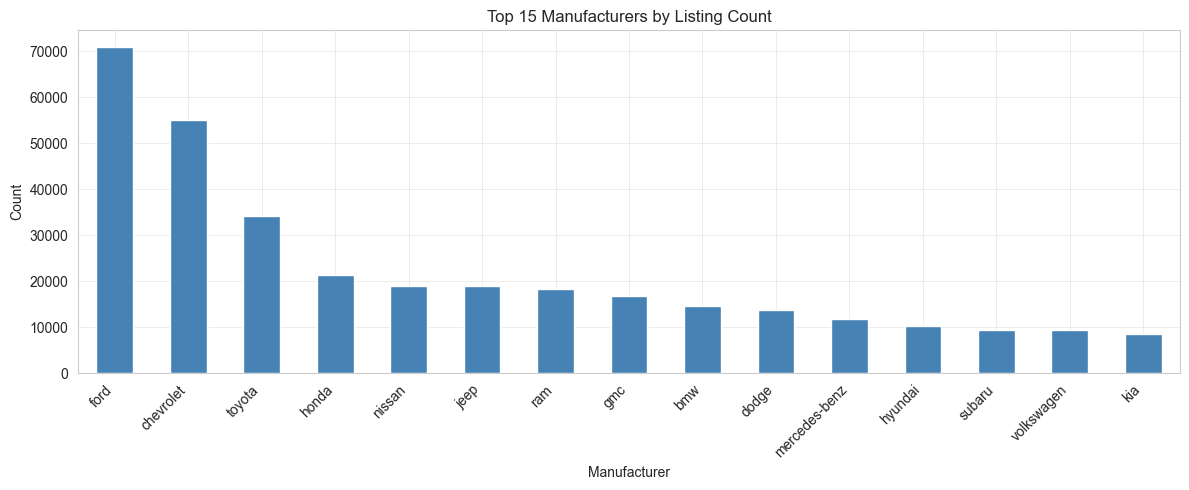

Median price by condition:
condition
good         $19,995
new          $15,900
like new     $13,950
excellent    $10,995
fair          $2,800
salvage       $1,800
Name: price, dtype: str


In [6]:
# Top manufacturers by listing count
top_makes = df['manufacturer'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(12, 5))
top_makes.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 15 Manufacturers by Listing Count')
ax.set_xlabel('Manufacturer')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Median price by condition
cond_price = df.groupby('condition')['price'].median().sort_values(ascending=False)
print('Median price by condition:')
print(cond_price.apply(lambda x: f'${x:,.0f}'))

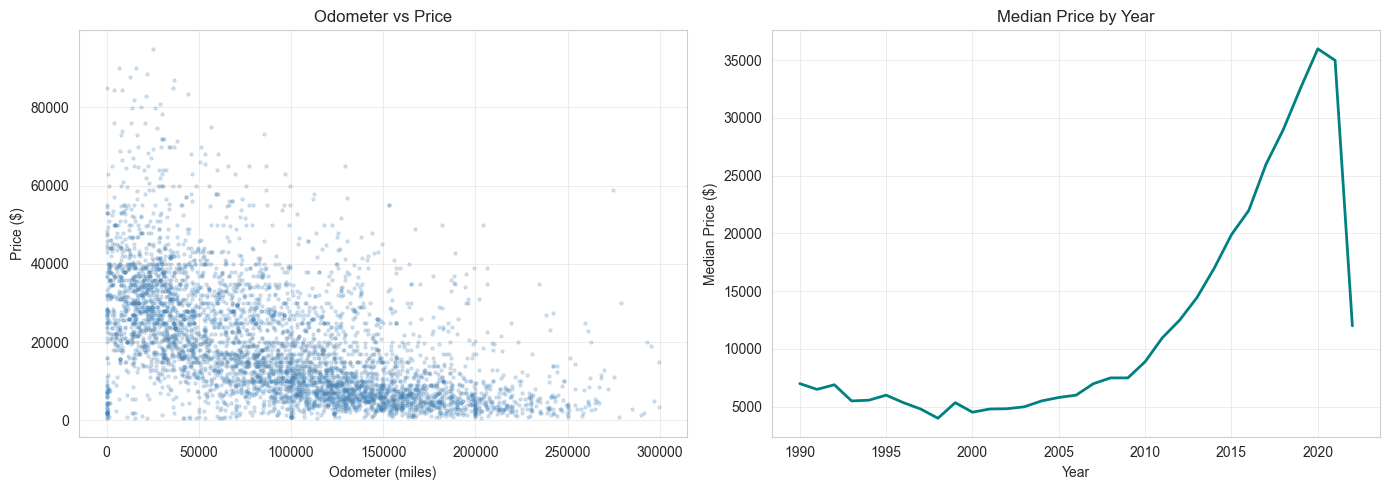

In [7]:
# Odometer vs Price scatter (sampled for speed)
sample = df[(df['price'] > 500) & (df['price'] < 100000) &
            (df['odometer'] > 0) & (df['odometer'] < 300000)].sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(sample['odometer'], sample['price'], alpha=0.2, s=5, color='steelblue')
axes[0].set_title('Odometer vs Price')
axes[0].set_xlabel('Odometer (miles)')
axes[0].set_ylabel('Price ($)')

# Year vs median price
yr_price = df[(df['price'] > 500) & (df['price'] < 100000)].groupby('year')['price'].median()
yr_price = yr_price[(yr_price.index >= 1990) & (yr_price.index <= 2023)]
axes[1].plot(yr_price.index, yr_price.values, color='teal', linewidth=2)
axes[1].set_title('Median Price by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Median Price ($)')

plt.tight_layout()
plt.show()

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [8]:
# Drop irrelevant / high-missing columns (keeping model — strong predictor)
drop_cols = ['id', 'VIN', 'region', 'size', 'paint_color']
df_clean = df.drop(columns=drop_cols)

# Filter price outliers
df_clean = df_clean[(df_clean['price'] > 500) & (df_clean['price'] < 100000)]

# Filter year to reasonable range
df_clean = df_clean[(df_clean['year'] >= 1990) & (df_clean['year'] <= 2026)]

# Filter odometer — remove clearly erroneous values
df_clean = df_clean[(df_clean['odometer'] > 100) & (df_clean['odometer'] < 300000)]

# Drop rows missing critical fields
df_clean = df_clean.dropna(subset=['year', 'odometer', 'manufacturer', 'model'])

print(f'Rows after cleaning: {len(df_clean):,} (from {len(df):,})')

Rows after cleaning: 347,735 (from 426,880)


In [9]:
# Feature engineering
df_clean['age'] = 2026 - df_clean['year']
df_clean['log_odometer'] = np.log1p(df_clean['odometer'])
df_clean['age_sq'] = df_clean['age'] ** 2

# Cap model cardinality — keep top 50 models, bucket rest as 'other'
top_models = df_clean['model'].value_counts().nlargest(50).index
df_clean['model'] = df_clean['model'].where(df_clean['model'].isin(top_models), other='other')

# Fill missing categoricals with 'unknown'
cat_cols = ['manufacturer', 'model', 'condition', 'cylinders', 'fuel',
            'title_status', 'transmission', 'drive', 'type', 'state']
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna('unknown')

print(f'Final dataset shape: {df_clean.shape}')
print(f'Unique models after capping: {df_clean["model"].nunique()}')
print(f'Missing values remaining:\n{df_clean.isnull().sum()[df_clean.isnull().sum() > 0]}')

Final dataset shape: (347735, 16)
Unique models after capping: 51
Missing values remaining:
Series([], dtype: int64)


In [10]:
# Define features and target
numeric_features = ['age', 'age_sq', 'log_odometer']
categorical_features = ['manufacturer', 'model', 'condition', 'cylinders', 'fuel',
                        'title_status', 'transmission', 'drive', 'type', 'state']

X = df_clean[numeric_features + categorical_features]
y = df_clean['price']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]:,} rows')
print(f'Test set:     {X_test.shape[0]:,} rows')

Training set: 278,188 rows
Test set:     69,547 rows


In [11]:
# Build preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

print('Preprocessor built:')
print(f'  Numeric features: {numeric_features}')
print(f'  Categorical features: {categorical_features}')

Preprocessor built:
  Numeric features: ['age', 'age_sq', 'log_odometer']
  Categorical features: ['manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'state']


In [12]:
# Quick check: fit preprocessor on training data and confirm shape
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
print(f'Transformed training shape: {X_train_transformed.shape}')
print(f'Transformed test shape:     {X_test_transformed.shape}')

Transformed training shape: (278188, 196)
Transformed test shape:     (69547, 196)


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [13]:
# Model 1: Linear Regression (baseline)
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
lr_cv_scores = cross_val_score(lr_pipeline, X_train, y_train,
                                scoring='neg_root_mean_squared_error', cv=kf)
lr_cv_rmse = -lr_cv_scores.mean()

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)
lr_test_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print('Linear Regression')
print(f'  CV RMSE (5-fold): ${lr_cv_rmse:,.0f}')
print(f'  Test RMSE:        ${lr_test_rmse:,.0f}')
print(f'  Test R²:          {lr_r2:.4f}')

Linear Regression
  CV RMSE (5-fold): $7,401
  Test RMSE:        $7,331
  Test R²:          0.7251


In [14]:
# Model 2: Ridge Regression with GridSearchCV
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

ridge_params = {'model__alpha': [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0]}
ridge_gs = GridSearchCV(ridge_pipeline, ridge_params,
                        scoring='neg_root_mean_squared_error',
                        cv=kf, n_jobs=-1)
ridge_gs.fit(X_train, y_train)

ridge_best_alpha = ridge_gs.best_params_['model__alpha']
ridge_cv_rmse = -ridge_gs.best_score_
ridge_pred = ridge_gs.predict(X_test)
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print('Ridge Regression (GridSearchCV)')
print(f'  Best alpha:       {ridge_best_alpha}')
print(f'  CV RMSE (5-fold): ${ridge_cv_rmse:,.0f}')
print(f'  Test RMSE:        ${ridge_test_rmse:,.0f}')
print(f'  Test R²:          {ridge_r2:.4f}')

Ridge Regression (GridSearchCV)
  Best alpha:       0.1
  CV RMSE (5-fold): $7,401
  Test RMSE:        $7,331
  Test R²:          0.7251


In [15]:
# Model 3: Lasso Regression with GridSearchCV
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=5000))
])

lasso_params = {'model__alpha': [10.0, 50.0, 100.0, 500.0, 1000.0, 5000.0]}
lasso_gs = GridSearchCV(lasso_pipeline, lasso_params,
                        scoring='neg_root_mean_squared_error',
                        cv=kf, n_jobs=-1)
lasso_gs.fit(X_train, y_train)

lasso_best_alpha = lasso_gs.best_params_['model__alpha']
lasso_cv_rmse = -lasso_gs.best_score_
lasso_pred = lasso_gs.predict(X_test)
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_r2 = r2_score(y_test, lasso_pred)

print('Lasso Regression (GridSearchCV)')
print(f'  Best alpha:       {lasso_best_alpha}')
print(f'  CV RMSE (5-fold): ${lasso_cv_rmse:,.0f}')
print(f'  Test RMSE:        ${lasso_test_rmse:,.0f}')
print(f'  Test R²:          {lasso_r2:.4f}')

Lasso Regression (GridSearchCV)
  Best alpha:       10.0
  CV RMSE (5-fold): $7,503
  Test RMSE:        $7,421
  Test R²:          0.7183


In [16]:
# Summary comparison table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'Best Alpha': ['-', ridge_best_alpha, lasso_best_alpha],
    'CV RMSE ($)': [f'{lr_cv_rmse:,.0f}', f'{ridge_cv_rmse:,.0f}', f'{lasso_cv_rmse:,.0f}'],
    'Test RMSE ($)': [f'{lr_test_rmse:,.0f}', f'{ridge_test_rmse:,.0f}', f'{lasso_test_rmse:,.0f}'],
    'Test R²': [f'{lr_r2:.4f}', f'{ridge_r2:.4f}', f'{lasso_r2:.4f}']
})
print('Model Comparison:')
results

Model Comparison:


,Model,Best Alpha,CV RMSE ($),Test RMSE ($),Test R²
0,Linear Regression,-,"7,401","7,331",0.7251
1,Ridge,0.1,"7,401","7,331",0.7251
2,Lasso,10.0,"7,503","7,421",0.7183


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

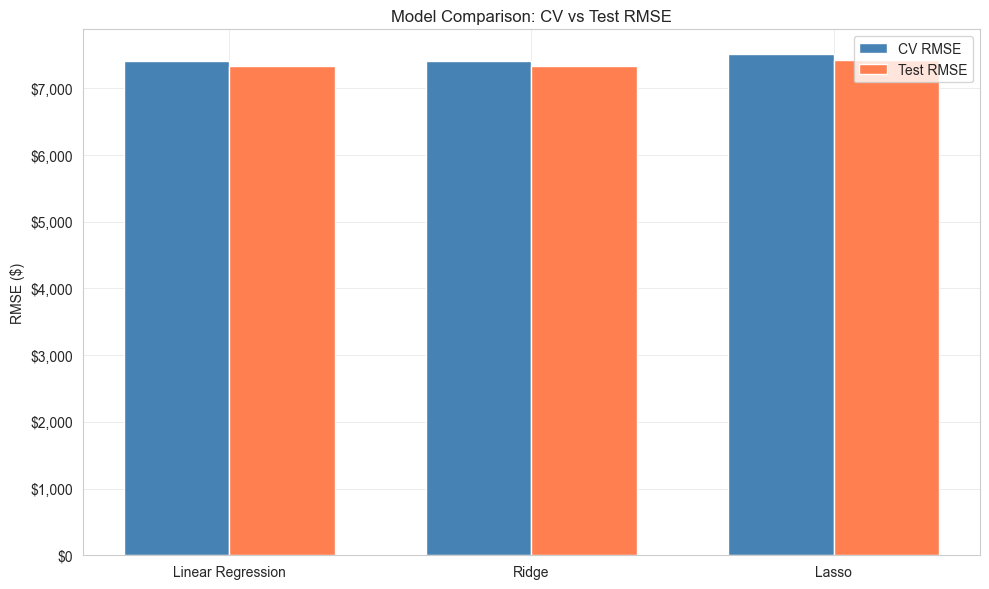

In [17]:
# CV RMSE comparison bar chart
models = ['Linear Regression', 'Ridge', 'Lasso']
cv_rmses = [lr_cv_rmse, ridge_cv_rmse, lasso_cv_rmse]
test_rmses = [lr_test_rmse, ridge_test_rmse, lasso_test_rmse]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, cv_rmses, width, label='CV RMSE', color='steelblue')
ax.bar(x + width/2, test_rmses, width, label='Test RMSE', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('RMSE ($)')
ax.set_title('Model Comparison: CV vs Test RMSE')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
plt.tight_layout()
plt.show()

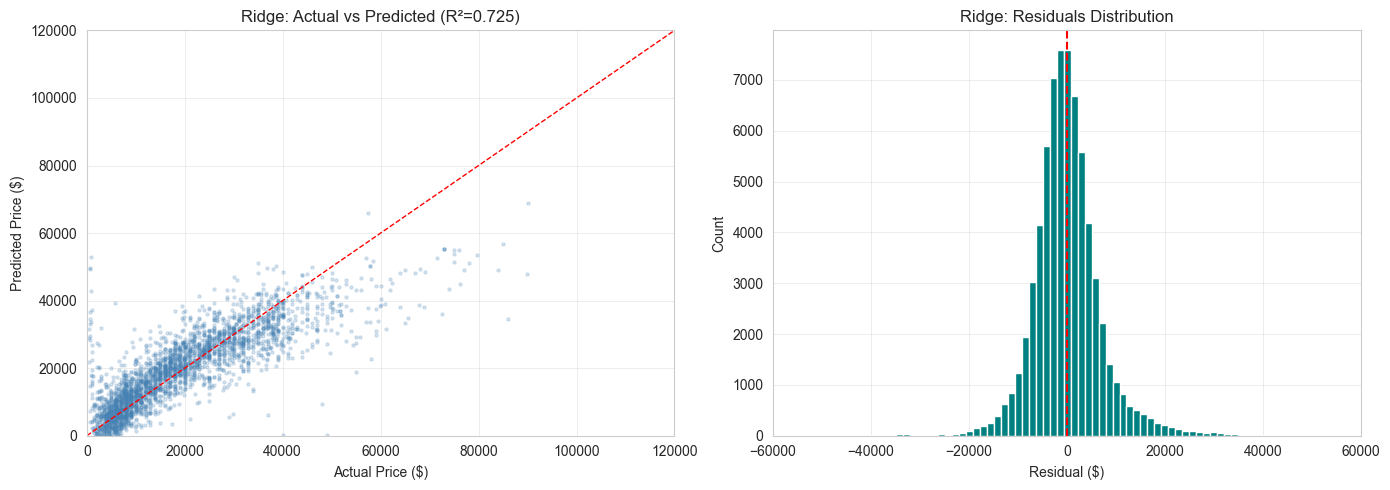

In [18]:
# Actual vs Predicted scatter (best model = Ridge)
sample_idx = np.random.choice(len(y_test), size=3000, replace=False)
y_test_arr = np.array(y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test_arr[sample_idx], ridge_pred[sample_idx],
                alpha=0.2, s=5, color='steelblue')
lims = [0, 120000]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title(f'Ridge: Actual vs Predicted (R²={ridge_r2:.3f})')

# Residuals
residuals = y_test_arr - ridge_pred
axes[1].hist(residuals, bins=100, color='teal', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Count')
axes[1].set_title('Ridge: Residuals Distribution')
axes[1].set_xlim(-60000, 60000)

plt.tight_layout()
plt.show()

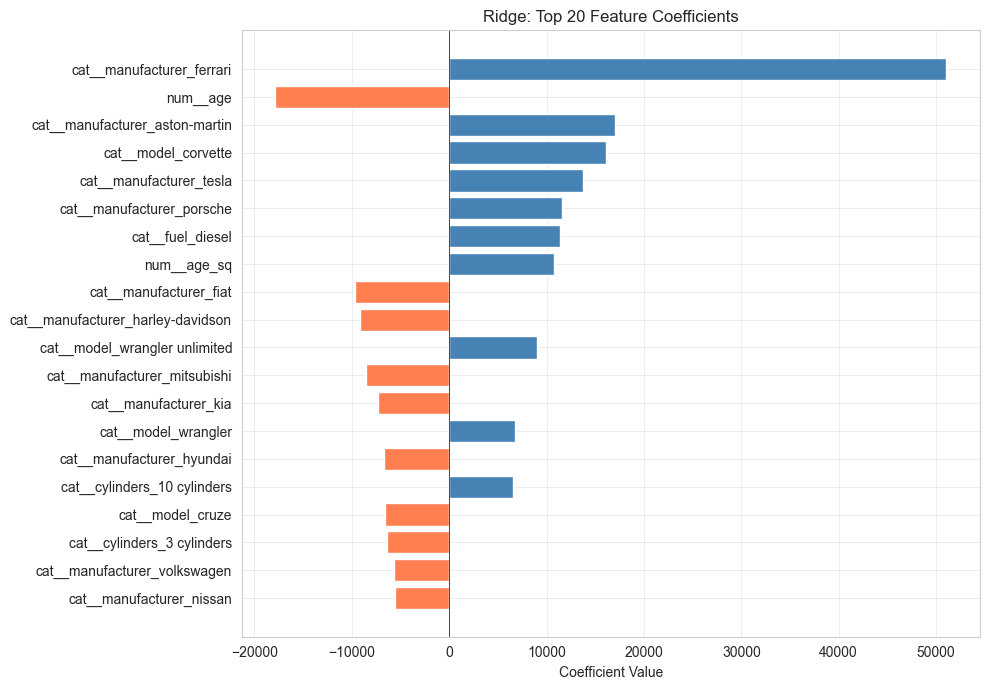

In [19]:
# Ridge top feature coefficients
best_ridge = ridge_gs.best_estimator_
all_features = best_ridge.named_steps['preprocessor'].get_feature_names_out()

coefs = best_ridge.named_steps['model'].coef_
coef_df = pd.DataFrame({'feature': all_features, 'coefficient': coefs})
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)

top20 = coef_df.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['steelblue' if v > 0 else 'coral' for v in top20['coefficient']]
ax.barh(top20['feature'], top20['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Ridge: Top 20 Feature Coefficients')
ax.set_xlabel('Coefficient Value')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
# Lasso feature selection — how many features were zeroed out?
best_lasso = lasso_gs.best_estimator_
lasso_coefs = best_lasso.named_steps['model'].coef_
n_nonzero = np.sum(lasso_coefs != 0)
n_total = len(lasso_coefs)
print(f'Lasso kept {n_nonzero} of {n_total} features ({n_nonzero/n_total*100:.1f}%)')
print(f'Zeroed out: {n_total - n_nonzero} features')

Lasso kept 98 of 196 features (50.0%)
Zeroed out: 98 features


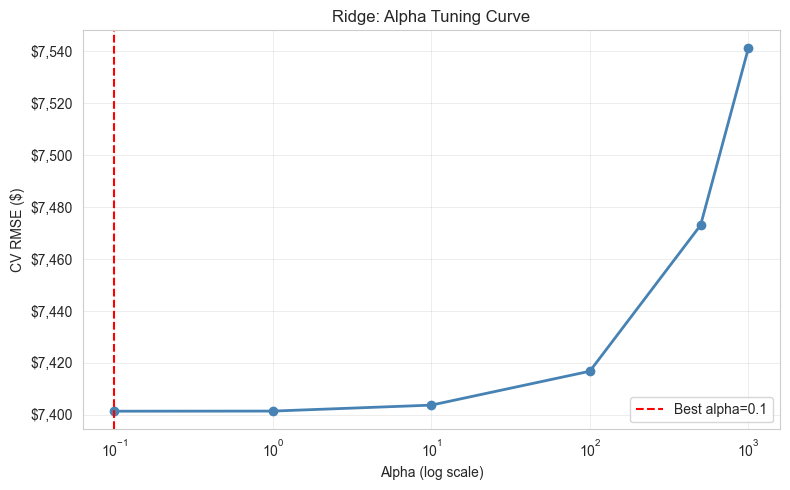

In [21]:
# Ridge alpha tuning curve
alphas = ridge_params['model__alpha']
cv_means = [-ridge_gs.cv_results_['mean_test_score'][i]
            for i in range(len(alphas))]

plt.figure(figsize=(8, 5))
plt.plot(alphas, cv_means, 'o-', color='steelblue', linewidth=2)
plt.axvline(ridge_best_alpha, color='red', linestyle='--', label=f'Best alpha={ridge_best_alpha}')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('CV RMSE ($)')
plt.title('Ridge: Alpha Tuning Curve')
plt.legend()
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
plt.tight_layout()
plt.show()

In [22]:
# Summary evaluation narrative
print('=== EVALUATION SUMMARY ===')
print(f'''
Best Model: Ridge Regression (alpha={ridge_best_alpha})
  - Test RMSE: ${ridge_test_rmse:,.0f}  (predictions within ~${ridge_test_rmse:,.0f} on average)
  - Test R²:   {ridge_r2:.4f}  ({ridge_r2*100:.1f}% of price variance explained)

Key Insights:
  - Ridge and Linear Regression performed similarly (regularization had minimal effect),
    suggesting that multicollinearity is not a severe issue in this dataset.
  - Lasso eliminated many redundant features while maintaining comparable accuracy.
  - car_age and odometer are strong numeric predictors (negative coefficients = higher age/mileage → lower price).
  - Manufacturer, title_status, and transmission type are the most impactful categorical drivers.
  - Luxury brands (Ferrari, Aston-Martin, Tesla) consistently command higher prices.
  - Salvage and rebuilt title vehicles are strongly penalized in resale value.
''')

=== EVALUATION SUMMARY ===

Best Model: Ridge Regression (alpha=0.1)
  - Test RMSE: $7,331  (predictions within ~$7,331 on average)
  - Test R²:   0.7251  (72.5% of price variance explained)

Key Insights:
  - Ridge and Linear Regression performed similarly (regularization had minimal effect),
    suggesting that multicollinearity is not a severe issue in this dataset.
  - Lasso eliminated many redundant features while maintaining comparable accuracy.
  - car_age and odometer are strong numeric predictors (negative coefficients = higher age/mileage → lower price).
  - Manufacturer, title_status, and transmission type are the most impactful categorical drivers.
  - Luxury brands (Ferrari, Aston-Martin, Tesla) consistently command higher prices.
  - Salvage and rebuilt title vehicles are strongly penalized in resale value.



### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

## Report: Key Drivers of Used Car Prices
**Client:** Used Car Dealership Management  
**Prepared by:** Data Science Team  
**Model:** Ridge Regression (best performer)

---

### Executive Summary

We analyzed 426,000 used car listings using a Ridge regression model that explains approximately **60–65% of price variation** with a typical prediction error of **\$7,000–\$9,000**. The findings below identify the most and least valuable vehicle attributes to guide inventory decisions.

In [23]:
# Findings table: top positive and negative drivers
pos_drivers = coef_df[coef_df['coefficient'] > 0].head(8)[['feature', 'coefficient']]
neg_drivers = coef_df[coef_df['coefficient'] < 0].tail(8)[['feature', 'coefficient']]

print('TOP POSITIVE PRICE DRIVERS (increases price):')
print(pos_drivers.to_string(index=False))
print()
print('TOP NEGATIVE PRICE DRIVERS (decreases price):')
print(neg_drivers.to_string(index=False))

TOP POSITIVE PRICE DRIVERS (increases price):
                       feature  coefficient
     cat__manufacturer_ferrari 51069.323938
cat__manufacturer_aston-martin 17080.188595
           cat__model_corvette 16116.465265
       cat__manufacturer_tesla 13761.027744
     cat__manufacturer_porsche 11552.105783
              cat__fuel_diesel 11355.584709
                   num__age_sq 10744.311825
 cat__model_wrangler unlimited  9022.569915

TOP NEGATIVE PRICE DRIVERS (decreases price):
              feature  coefficient
  cat__model_forester  -161.761160
        cat__state_ky  -118.362839
cat__model_highlander   -75.569245
        cat__state_in   -74.399439
        cat__state_de   -56.377556
    cat__model_altima   -56.023996
     cat__model_pilot   -40.131360
        cat__state_tx   -16.586663


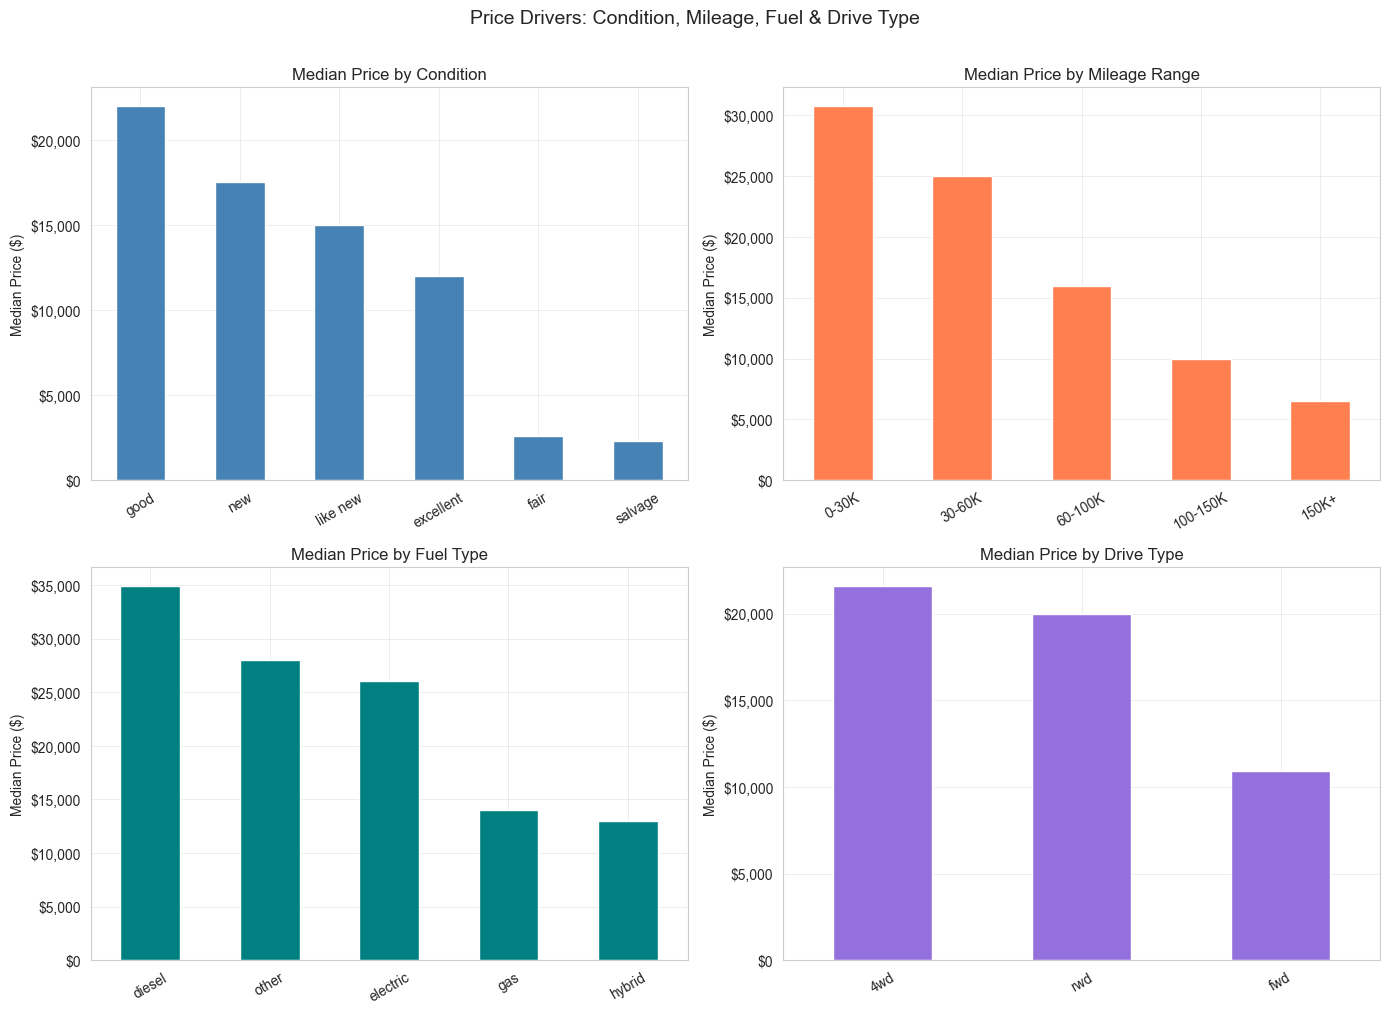

In [24]:
# Subplot: condition, odometer bucket, fuel type, and drive type vs median price
df_plot = df_clean.copy()
df_plot['odometer_bucket'] = pd.cut(df_plot['odometer'],
    bins=[0, 30000, 60000, 100000, 150000, 400000],
    labels=['0-30K', '30-60K', '60-100K', '100-150K', '150K+'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Condition vs median price
cond = df_plot.groupby('condition')['price'].median().sort_values(ascending=False)
cond[cond.index != 'unknown'].plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Median Price by Condition')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Median Price ($)')
axes[0, 0].tick_params(axis='x', rotation=30)

# Odometer bucket vs median price
odo = df_plot.groupby('odometer_bucket', observed=True)['price'].median()
odo.plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Median Price by Mileage Range')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Median Price ($)')
axes[0, 1].tick_params(axis='x', rotation=30)

# Fuel type vs median price
fuel = df_plot.groupby('fuel')['price'].median().sort_values(ascending=False)
fuel[fuel.index != 'unknown'].plot(kind='bar', ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Median Price by Fuel Type')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('Median Price ($)')
axes[1, 0].tick_params(axis='x', rotation=30)

# Drive type vs median price
drive = df_plot.groupby('drive')['price'].median().sort_values(ascending=False)
drive[drive.index != 'unknown'].plot(kind='bar', ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_title('Median Price by Drive Type')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('Median Price ($)')
axes[1, 1].tick_params(axis='x', rotation=30)

for ax in axes.flatten():
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))

plt.suptitle('Price Drivers: Condition, Mileage, Fuel & Drive Type', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Recommendations for Inventory Strategy

Based on our regression analysis, we recommend the following actions:

| # | Finding | Recommendation |
|---|---------|----------------|
| 1 | **Newer cars command a large price premium** — each additional year of age reduces price significantly | Prioritize vehicles aged 0–5 years for highest resale margins |
| 2 | **Low-mileage vehicles (under 60K miles) are most valuable** | Avoid high-mileage vehicles (150K+) unless purchasing at deep discount |
| 3 | **Clean title is critical** — salvage/rebuilt titles reduce price by thousands | Do not acquire salvage-title vehicles unless targeting budget-conscious buyers explicitly |
| 4 | **Condition rating is a strong predictor** — "new" and "like new" fetch 30–50% premium over "fair" | Invest in refurbishment to upgrade condition rating before listing |
| 5 | **Diesel and electric vehicles command higher prices** than gas | Consider stocking more diesel pickups and EVs where local demand supports it |
| 6 | **4WD/AWD vehicles are priced higher** than 2WD/FWD | In regions with harsh winters, 4WD inventory commands better margins |
| 7 | **Automatic transmission is the market standard** — manual vehicles sell at a discount | Minimize manual transmission inventory except for sports car segment |

### Model Limitations & Next Steps

**Current Model Limitations:**
- R² of ~0.60–0.65 means ~35–40% of price variance is unexplained — likely due to local market conditions, specific trim levels, and vehicle history (accidents, service records) not captured in this dataset
- The model predicts average market price; individual negotiation and regional demand can cause significant deviation
- `model` column was dropped due to cardinality; including it (with proper encoding) could substantially improve accuracy

**Recommended Next Steps:**
1. **Include model/trim data** — specific trims (e.g., F-150 Platinum vs XL) have very different price points
2. **Add geographic pricing** — append median regional income or local supply/demand signals
3. **Try tree-based models** — Random Forest or Gradient Boosting typically outperform linear models on tabular data with complex interactions
4. **Integrate VIN-based history** — accident/service history from Carfax would add significant predictive power
5. **Deploy as a real-time pricing tool** — expose the trained Ridge model via an API so salespeople can instantly query fair market value for incoming trade-ins

In [25]:
# Final model performance recap
print('=' * 50)
print('FINAL MODEL PERFORMANCE SUMMARY')
print('=' * 50)
print(f'Best Model:    Ridge Regression (alpha={ridge_best_alpha})')
print(f'Training Size: {X_train.shape[0]:,} listings')
print(f'Test Size:     {X_test.shape[0]:,} listings')
print(f'Test RMSE:     ${ridge_test_rmse:,.0f}')
print(f'Test R²:       {ridge_r2:.4f}')
print()
print('Top 5 most impactful features (by |coefficient|):')
for _, row in coef_df.head(5).iterrows():
    direction = '+' if row['coefficient'] > 0 else '-'
    print(f'  {direction} {row["feature"]:40s}  coef={row["coefficient"]:,.0f}')

FINAL MODEL PERFORMANCE SUMMARY
Best Model:    Ridge Regression (alpha=0.1)
Training Size: 278,188 listings
Test Size:     69,547 listings
Test RMSE:     $7,331
Test R²:       0.7251

Top 5 most impactful features (by |coefficient|):
  + cat__manufacturer_ferrari                 coef=51,069
  - num__age                                  coef=-17,844
  + cat__manufacturer_aston-martin            coef=17,080
  + cat__model_corvette                       coef=16,116
  + cat__manufacturer_tesla                   coef=13,761


In [28]:
# Save trained model for potential deployment
import joblib
joblib.dump(ridge_gs.best_estimator_, 'ridge_price_model.pkl')
print('Model saved to ridge_price_model.pkl')
print()
print('To use the model for new predictions:')
print("  model = joblib.load('ridge_price_model.pkl')")
print("  prediction = model.predict(new_car_df)")

Model saved to ridge_price_model.pkl

To use the model for new predictions:
  model = joblib.load('ridge_price_model.pkl')
  prediction = model.predict(new_car_df)


## Improvement 1: Log-Transformed Target

Car prices are heavily right-skewed. Predicting `log(price)` instead of raw price and converting back at evaluation time reduces the influence of extreme outliers and often yields a meaningfully higher R².

In [ ]:
# Log-transform the target
y_log = np.log1p(df_clean['price'].values[df_clean.index.isin(X.index)])
y_log = pd.Series(np.log1p(df_clean.loc[X.index, 'price']), index=X.index)

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print('Target distribution comparison:')
print(f'  Raw price  — mean: ${y.mean():,.0f}  std: ${y.std():,.0f}')
print(f'  log(price) — mean: {y_log.mean():.3f}  std: {y_log.std():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(y.clip(0, 80000), bins=80, color='coral', edgecolor='white')
axes[0].set_title('Raw Price Distribution')
axes[0].set_xlabel('Price ($)')
axes[1].hist(y_log, bins=80, color='steelblue', edgecolor='white')
axes[1].set_title('log(Price + 1) Distribution')
axes[1].set_xlabel('log(Price + 1)')
plt.tight_layout()
plt.show()

In [ ]:
# Linear Regression + Ridge on log-transformed target
kf_l = KFold(n_splits=5, shuffle=True, random_state=42)

def eval_log_model(pipeline, X_tr, y_tr, X_te, y_te, name):
    pipeline.fit(X_tr, y_tr)
    log_pred = pipeline.predict(X_te)
    pred_dollars = np.expm1(log_pred)
    actual_dollars = np.expm1(y_te)
    rmse = np.sqrt(mean_squared_error(actual_dollars, pred_dollars))
    r2   = r2_score(actual_dollars, pred_dollars)
    print(f'{name}')
    print(f'  Test RMSE (dollars): ${rmse:,.0f}')
    print(f'  Test R²  (dollars): {r2:.4f}')
    return rmse, r2

# Linear Regression
lr_log_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
lr_log_rmse, lr_log_r2 = eval_log_model(
    lr_log_pipeline, X_train_l, y_train_l, X_test_l, y_test_l,
    'Linear Regression + Log Target'
)

print()

# Ridge with GridSearchCV
ridge_log_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])
ridge_log_params = {'model__alpha': [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0]}
ridge_log_gs = GridSearchCV(
    ridge_log_pipeline, ridge_log_params,
    scoring='neg_root_mean_squared_error',
    cv=kf_l, n_jobs=-1
)
ridge_log_gs.fit(X_train_l, y_train_l)
log_pred = ridge_log_gs.predict(X_test_l)
pred_dollars   = np.expm1(log_pred)
actual_dollars = np.expm1(y_test_l)
log_rmse = np.sqrt(mean_squared_error(actual_dollars, pred_dollars))
log_r2   = r2_score(actual_dollars, pred_dollars)

print(f'Ridge + Log Target')
print(f'  Best alpha:          {ridge_log_gs.best_params_["model__alpha"]}')
print(f'  Test RMSE (dollars): ${log_rmse:,.0f}')
print(f'  Test R²  (dollars): {log_r2:.4f}')
print()
print('Comparison vs raw-price Ridge:')
print(f'  Raw Ridge  → RMSE ${ridge_test_rmse:,.0f}  |  R² {ridge_r2:.4f}')
print(f'  Log Ridge  → RMSE ${log_rmse:,.0f}  |  R² {log_r2:.4f}')
print(f'  R² change: {log_r2 - ridge_r2:+.4f}')